# PREFINAL EXAMINATION - LUMANGLAS

# Step 1: Formulate Research Questions

How do factors such as distance, weather, traffic level, time of day, vehicle type, preparation time, and courier experience affect delivery time?

# Variables

Independent Variables: 
* Distance_km
* Preparation_Time_min

Dependent Variable:
*  Delivery_Time_min

# Objectives
The objective of this research is to analyze the impact of various factors on delivery time.

# Step 2: Data Cleaning

This block of code is importing necessary libraries for data analysis and machine learning.

In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

A. Load the dataset

In [5]:
df = pd.read_csv('Food_Delivery_Times.csv')
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


B. Display the first few rows of the DataFrame

In [6]:

df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


B. Display summary statistics of the DataFrame

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


C. This code provides a statistical summary of the DataFrame 'df', including count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum values for each numerical column in the dataset. It helps to understand the distribution and central tendency of the data.

In [8]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


D. Check for missing values

In [9]:

df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

E. Check for duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

F. Remove duplicates if any

In [11]:
df.drop_duplicates(inplace=True)

# Step 3: Explonatory Data Analysis

Performing exploratory data analysis (EDA) on the dataset to understand the distribution of the data, identify any outliers, and visualize the relationships between the variables.

A. Scatterplot - To show how the delivery time changes with respect to each independent variable.

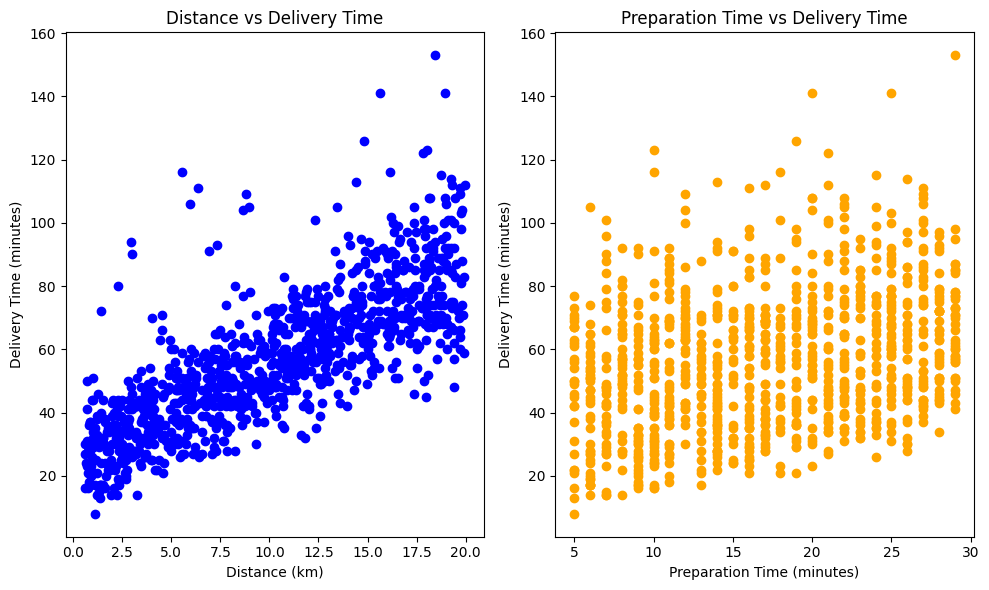

In [12]:
plt.figure(figsize=(10,6))

plt.subplot(1, 2, 1)
plt.scatter(df['Distance_km'], df['Delivery_Time_min'], color='blue')
plt.title('Distance vs Delivery Time')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (minutes)')

plt.subplot(1, 2, 2)
plt.scatter(df['Preparation_Time_min'], df['Delivery_Time_min'], color='orange')
plt.title('Preparation Time vs Delivery Time')
plt.xlabel('Preparation Time (minutes)')
plt.ylabel('Delivery Time (minutes)')

plt.tight_layout()
plt.show()


This code creates a figure with two subplots. The first subplot is a scatter plot that shows the relationship between 'Distance_km' and 'Delivery_Time_min', where the x-axis represents the distance in kilometers and the y-axis represents the delivery time in minutes. The points are colored blue. The second subplot is another scatter plot that shows the relationship between 'Preparation_Time_min' and 'Delivery_Time_min', where the x-axis represents the preparation time in minutes and the y-axis represents the delivery time in minutes. The points in this plot are colored orange. Finally, `plt.tight_layout()` is called to adjust the spacing between the subplots, and `plt.show()` is used to display the figure.

B. Pairplot - To visualize the relationships between all variables in the dataset

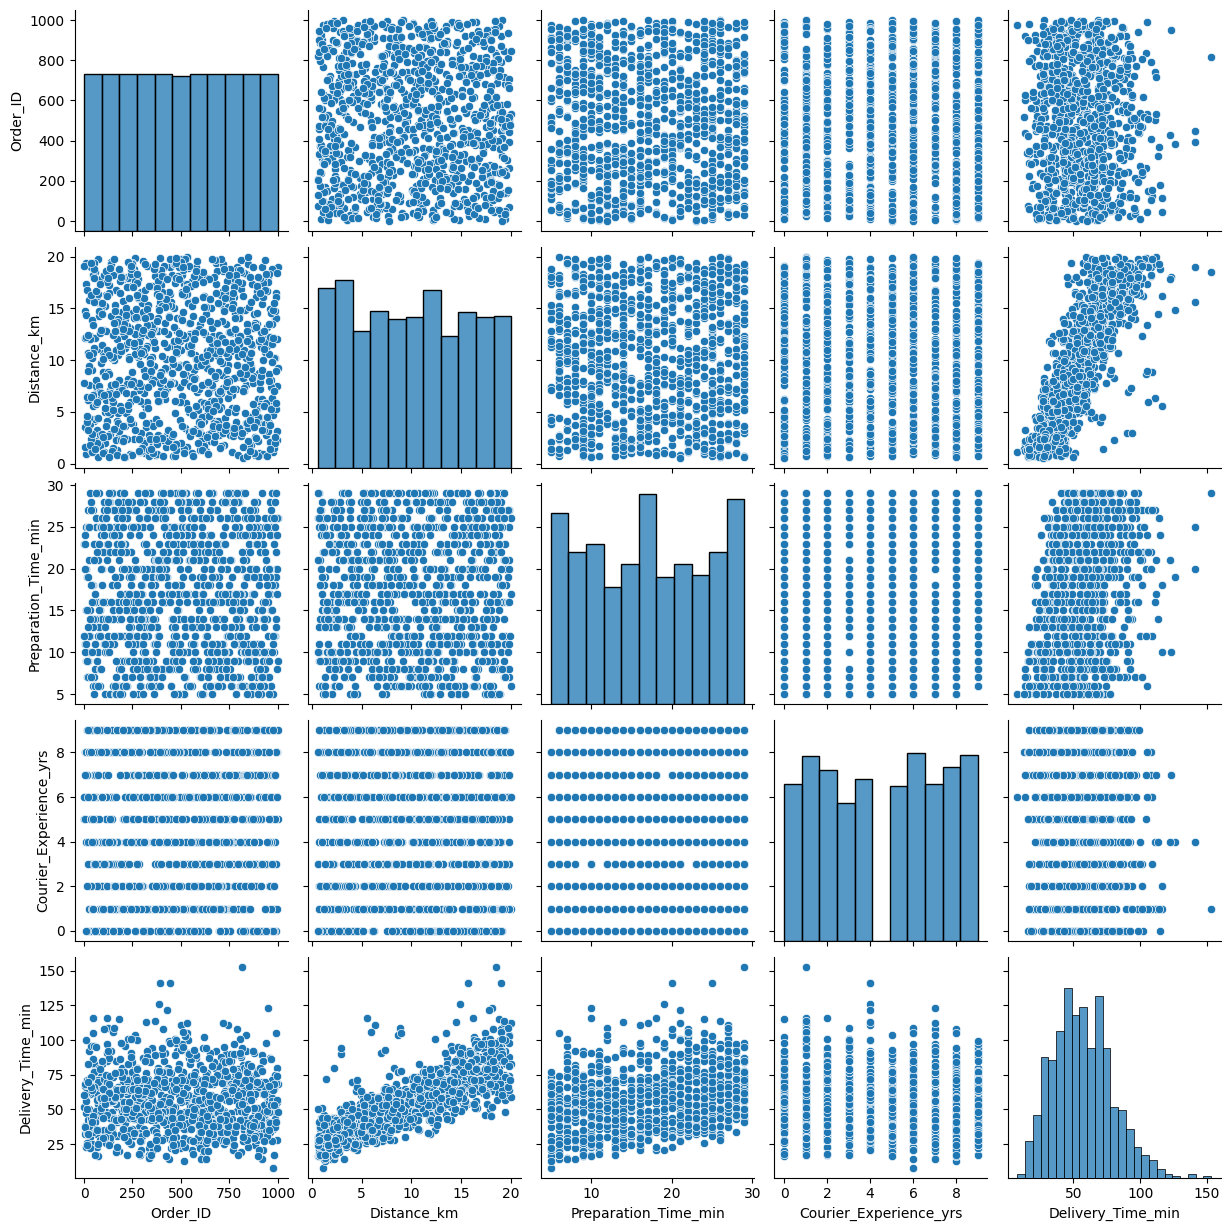

In [13]:
sns.pairplot(df)
plt.show()

The pairplot shows the relationships between the features and the target variable.

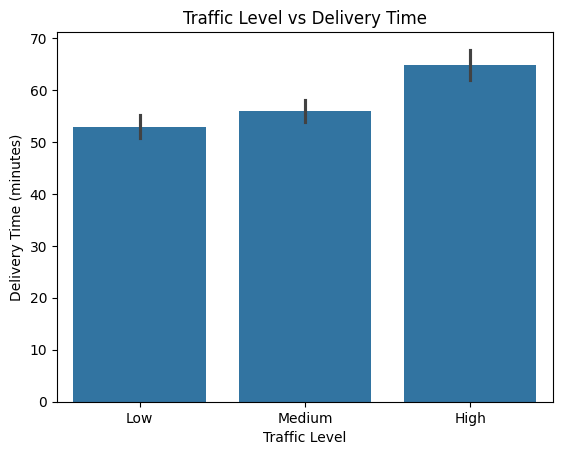

In [14]:
sns.barplot(x='Traffic_Level', y='Delivery_Time_min', data=df)
plt.title('Traffic Level vs Delivery Time')
plt.xlabel('Traffic Level')
plt.ylabel('Delivery Time (minutes)')
plt.show()

# Step 4: Model Training

Model training involves splitting the dataset into a training set and a testing set. The training set is used to fit the linear regression model, where the model learns the relationship between the independent variables (Distance_km and Preparation_Time_min) and the dependent variable (Delivery_Time_min). The model estimates the coefficients for each independent variable, which represent their impact on delivery time. After training, we can evaluate the model's performance using the testing set, which was not used during training, to see how well it predicts delivery times based on the independent variables.


This block of code is splitting the dataset into training and testing sets.

In [15]:
x = df[['Distance_km', 'Preparation_Time_min']]
y = df['Delivery_Time_min']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Train the model, evaluate it, and print the coefficients

In [16]:
model = LinearRegression()
model.fit(x_train, y_train)

print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
})

print(coefficients)

Intercept: 9.530656489425084
                Feature  Coefficient
0           Distance_km     3.037216
1  Preparation_Time_min     0.986056


It makes predictions using the trained model on the test set and evaluates the model's performance using various metrics.

This block of code is using the trained linear regression model to make predictions on the test set (x_test) and then creating a DataFrame to compare the actual delivery times (y_test) with the predicted delivery times (y_pred). Finally, it prints the results.


In [17]:
y_pred = model.predict(x_test)
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results)

     Actual  Predicted
521      32  41.404803
737      68  65.951345
740      39  35.605798
660      44  43.309936
411      85  85.179003
..      ...        ...
408      78  79.651269
332      28  28.802433
208      60  56.627091
613      45  44.907992
78       48  42.718718

[200 rows x 2 columns]


# Step 5: Performance Evaluation

This refers to the process of assessing how well a machine learning model performs on unseen data.

In [18]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')

Mean Absolute Error: 7.680351163763087
Mean Squared Error: 120.43753932898672
Root Mean Squared Error: 10.974403825674846
R-squared: 0.7313023400053361


The model's performance can be evaluated using the metrics above. A lower MAE, MSE, and RMSE indicate better predictive accuracy, while an R-squared value closer to 1 indicates a better fit of the model to the data.

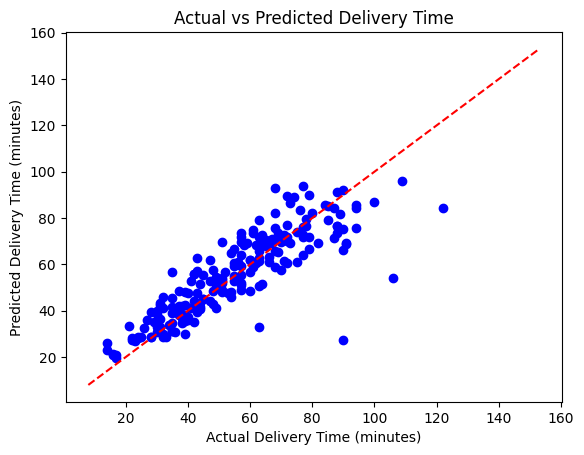

In [19]:
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel('Actual Delivery Time (minutes)')
plt.ylabel('Predicted Delivery Time (minutes)')
plt.title('Actual vs Predicted Delivery Time')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

The scatter plot of actual vs predicted delivery times shows how well the model's predictions align with the actual values. Each point represents a test sample, where the x-coordinate is the actual delivery time and the y-coordinate is the predicted delivery time. The red dashed line represents perfect predictions. Points close to this line indicate accurate predictions, while points farther away indicate larger errors.

The block of code calculates the residuals, which are the differences between the actual delivery times (y_test) and the predicted delivery times (y_pred). It then creates a scatter plot of the predicted delivery times on the x-axis and the residuals on the y-axis. A horizontal line is drawn at y=0 to indicate where the residuals would be if the predictions were perfect. This plot helps to visualize any patterns in the residuals, which can indicate issues with the model such as non-linearity.

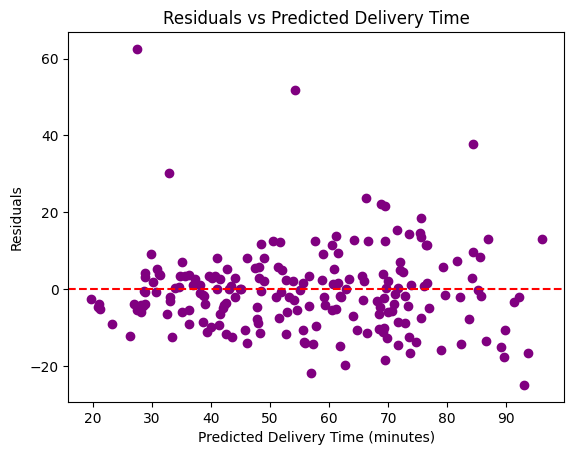

In [20]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Delivery Time (minutes)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Delivery Time')
plt.show()

In [24]:
new_data = pd.DataFrame({
    'Distance_km': [5.0],
    'Preparation_Time_min': [15]
})

predicted_time = model.predict(new_data)
print("Predicted Delivery Time:", predicted_time[0])

Predicted Delivery Time: 39.50758150837957


In [ ]:
# exporting the model 
import pickle
with open('delivery_time_model.pkl', 'wb') as file:
    pickle.dump(model, file)

### Reflection and Analysis 

Is the model reliable? Justify using results. 
- The model appears to be reasonably reliable based on the evaluation metrics. The R-squared value indicates that a significant portion of the variance in delivery time is explained by the model, and the MAE and RMSE values suggest that the predictions are relatively close to the actual values. However, it's important to consider the context of the data and any potential limitations before making a final judgment on reliability.

Identify limitations of the model and dataset
-  The limitation of the model is that it only considers two features (Distance_km and Preparation_Time_min) to predict delivery time, which may not capture all the factors influencing delivery time, such as traffic conditions, weather, or driver experience. Additionally, the dataset may have a limited number of samples or may not be representative of all delivery scenarios, which could affect the model's generalizability and accuracy.

Which variable contributes the most to AQI? Justify using EDA and coefficients?
- Distance contributes the most to delivery time. This is evident from the coefficient of distance which is higher than that of preparation time. Additionally, the scatter plot of distance vs delivery time shows a stronger positive correlation compared to preparation time vs delivery time.

If the strongest predictor is removed, what will happen to model performance? Explain logically?
- Removing the strongest predictor would likely lead to a decrease in model performance, as it would remove a key variable that explains a significant portion of the variance in delivery time. This could result in higher error metrics (MAE, MSE, RMSE) and a lower R-squared value, indicating that the model is less effective at predicting delivery time without that variable.

Does correlation imply causation in this dataset? Explain using an example?
- Correlation does not imply causation in this dataset. For example, if we find a strong correlation between preparation time and delivery time, it does not necessarily mean that longer preparation times cause longer delivery times. There could be other underlying factors, such as the complexity of the order or the efficiency of the kitchen staff, that influence both preparation time and delivery time. Therefore, while there may be a relationship between the two variables, we cannot conclude that one causes the other without further investigation.